<a href="https://colab.research.google.com/github/wsr3/ECON571_lab_2019S/blob/master/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 实验5：多元线性回归
本次实验首先以教材81页的案例为例，演示和练习多元回归分析，包括参数估计、t检验、F检验等。


## 表3.3案例
### 读取数据

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
np.random.seed(42)  # 设置随机种子，可复现

# 配置 matplotlib 中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'STHeiti', 'PingFang SC', 'Hiragino Sans GB']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [ ]:
# 读取Excel数据的“案例”sheet，跳过前两行，header=None表示不使用任何行作为列名，我们用names手动给各列命名
column_names = [
    'region',                      # 地区
    'education_expenditure',       # 地方一般公共预算教育支出（亿元）
    'population',                  # 年末人口数（万人）
    'local_revenue',               # 地方一般公共预算收入（亿元）
    'education_ratio',             # 教育支出在地方一般公共预算支出中的比重%
    'education_price_index',       # 教育消费价格指数(上年=100）
    'percapita_education_consumption'  # 居民人均教育文化娱乐消费（元/人）
]
raw = pd.read_excel('3 第三章 案例与习题数据.xlsx', sheet_name='案例', skiprows=2, header=None, names=column_names)
df = raw.copy()
print(f"数据大小: {df.shape}")
df.head()


数据大小: (31, 7)


,region,education_expenditure,population,local_revenue,education_ratio,education_price_index,percapita_education_consumption
0,北京,1138.29,2189,5483.89,16.00,100.9,2766.0
1,天津,442.91,1387,1923.11,14.05,104.9,2253.7
2,河北,1596.26,7464,3826.46,17.69,103.3,1799.1
3,山西,733.36,3490,2296.57,14.35,101.9,1608.4
4,内蒙古,642.17,2403,2051.20,12.19,100.7,1835.9


### 数据探索和可视化

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   region                           31 non-null     object 
 1   education_expenditure            31 non-null     float64
 2   population                       31 non-null     int64  
 3   local_revenue                    31 non-null     float64
 4   education_ratio                  31 non-null     float64
 5   education_price_index            31 non-null     float64
 6   percapita_education_consumption  31 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 1.8+ KB


In [ ]:
df.describe()

,education_expenditure,population,local_revenue,education_ratio,education_price_index,percapita_education_consumption
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,1118.911935,4548.806452,3230.425161,15.700968,101.951613,1954.248387
std,721.675219,3053.969553,2824.276334,2.683465,1.131038,538.828788
min,208.420000,366.000000,220.990000,10.320000,99.900000,550.900000
25%,652.580000,2445.500000,1597.080000,14.065000,101.000000,1707.000000
50%,1031.570000,3955.000000,2296.570000,15.920000,101.900000,1835.800000
75%,1293.555000,6286.500000,3997.650000,17.640000,102.600000,2187.300000
max,3510.560000,12624.000000,12923.850000,20.330000,104.900000,3662.900000


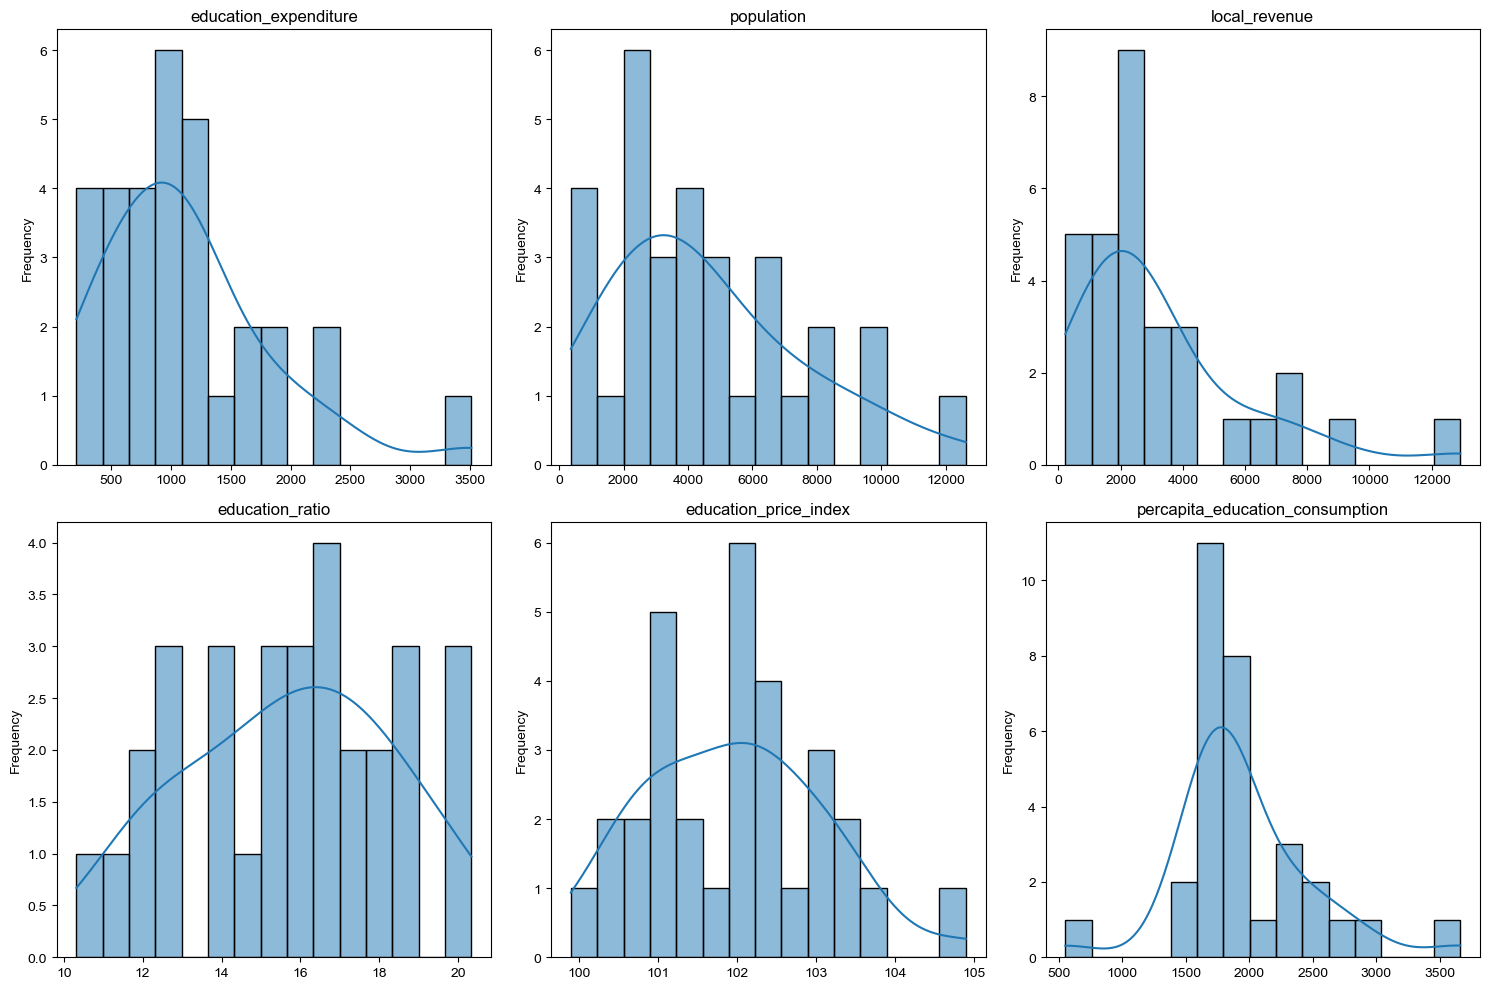

In [ ]:
# 选择所有数值变量（排除region）
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 创建子图，将所有变量的直方图画在一个图中
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # 将2D数组展平为1D数组

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True, bins=15)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<Axes: >

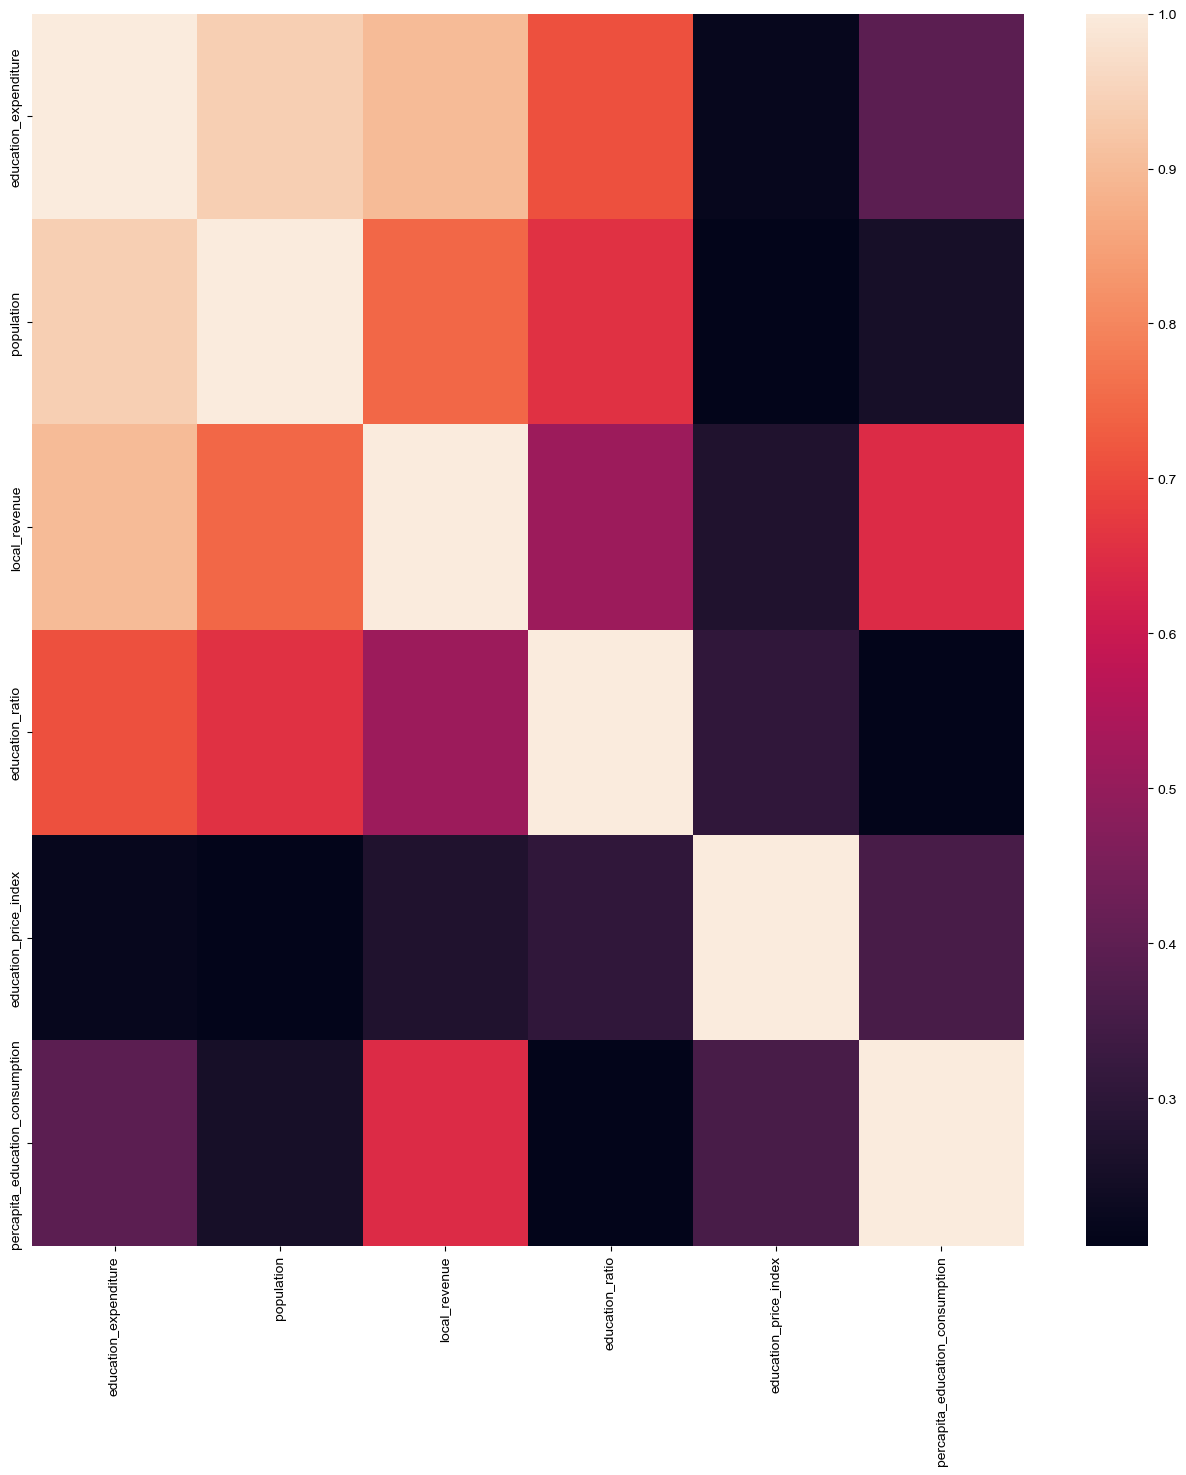

In [ ]:
plt.figure(figsize=(16, 16))
corrs = df[numeric_cols].corr()
sns.heatmap(corrs)

### 参数估计
模型：education_expenditure = $\beta_1$ + $\beta_2$ population + $\beta_3$ local_revenue + $\beta_4$ education_ratio + $\beta_5$ education_price_index + $\beta_6$ percapita_education_consumption

In [ ]:
my_model = smf.ols('education_expenditure ~ population + local_revenue + education_ratio + education_price_index + percapita_education_consumption', data=df).fit()
my_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     education_expenditure   R-squared:                       0.989
Model:                               OLS   Adj. R-squared:                  0.987
Method:                    Least Squares   F-statistic:                     443.5
Date:                   Tue, 04 Nov 2025   Prob (F-statistic):           1.47e-23
Time:                           09:11:03   Log-Likelihood:                -177.81
No. Observations:                     31   AIC:                             367.6
Df Residuals:                         25   BIC:                             376.2
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                        2331.0370   1481.738      1.573      0.128    -720.659    5382.733
population                          0.1101      0.009     11.736      0.000       0.091       0.129
local_revenue                       0.1372      0.011     11.966      0.000       0.114       0.161
education_ratio                    42.5752      7.755      5.490      0.000      26.603      58.547
education_price_index             -25.4277     14.966     -1.699      0.102     -56.251       5.395
percapita_education_consumption    -0.1188      0.043     -2.767      0.010      -0.207      -0.030
==============================================================================
Omnibus:                        4.156   Durbin-Watson:                   2.281
Prob(Omnibus):                  0.125   Jarque-Bera (JB):                2.864
Skew:                          -0.722   Prob(JB):                        0.239
Kurtosis:                       3.363   Cond. No.                     6.90e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.9e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

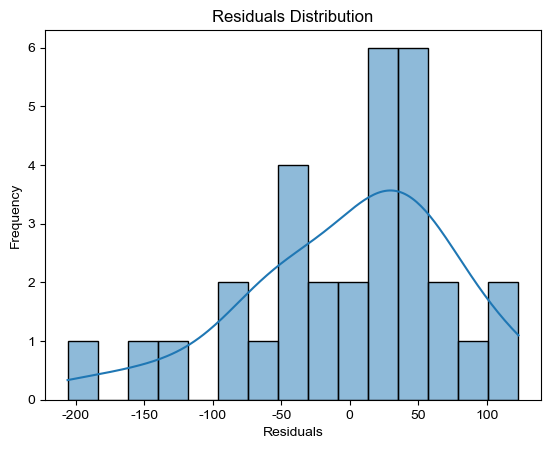

In [ ]:
# 得到模型残差
res = my_model.resid
# 画残差分布图
sns.histplot(res, kde=True, bins=15)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')
plt.show()


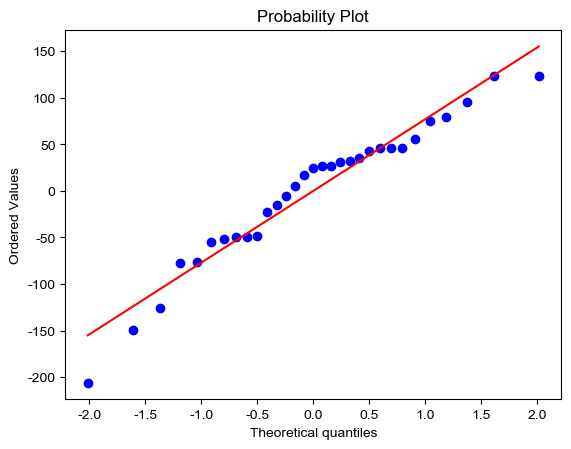

In [ ]:
# 画残差分布QQ plot
stats.probplot(res, plot=plt)
plt.show()


### 模型改进
残差分布左偏，这大概率是由于教育支出、人口和财政支出三个指数增长变量都是右偏，尝试对这三个变量取log再估计，但注意变换后参数的解释含义需要改变。

In [ ]:
my_model2 = smf.ols('np.log(education_expenditure) ~ np.log(population) + np.log(local_revenue) + education_ratio + education_price_index + percapita_education_consumption', data=df).fit()
my_model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                 
=========================================================================================
Dep. Variable:     np.log(education_expenditure)   R-squared:                       0.964
Model:                                       OLS   Adj. R-squared:                  0.957
Method:                            Least Squares   F-statistic:                     133.7
Date:                           Tue, 04 Nov 2025   Prob (F-statistic):           3.34e-17
Time:                                   09:26:41   Log-Likelihood:                 19.529
No. Observations:                             31   AIC:                            -27.06
Df Residuals:                                 25   BIC:                            -18.45
Df Model:                                      5                                         
Covariance Type:                       nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           7.9809      2.566      3.110      0.005       2.695      13.267
np.log(population)                  0.3077      0.075      4.113      0.000       0.154       0.462
np.log(local_revenue)               0.4388      0.088      4.980      0.000       0.257       0.620
education_ratio                     0.0501      0.013      3.813      0.001       0.023       0.077
education_price_index              -0.0741      0.026     -2.883      0.008      -0.127      -0.021
percapita_education_consumption    -0.0001   8.84e-05     -1.656      0.110      -0.000    3.57e-05
==============================================================================
Omnibus:                        1.211   Durbin-Watson:                   1.576
Prob(Omnibus):                  0.546   Jarque-Bera (JB):                0.512
Skew:                          -0.297   Prob(JB):                        0.774
Kurtosis:                       3.210   Cond. No.                     2.02e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.02e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

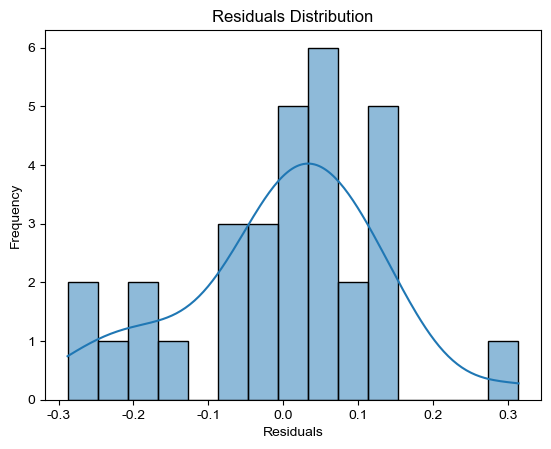

In [ ]:
res2 = my_model2.resid
sns.histplot(res2, kde=True, bins=15)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')
plt.show()


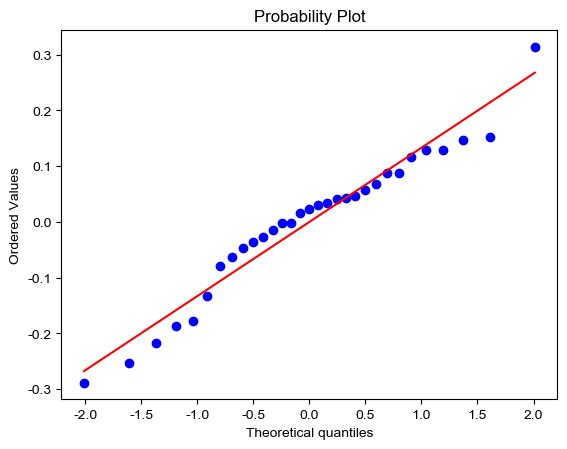

In [ ]:
# 画残差分布QQ plot
stats.probplot(res2, plot=plt)
plt.show()

## 练习题3.2
TODO

## 练习题3.3
TODO

## 练习题3.6
TODO